In [4]:
import pandas as pd
import numpy as np

print("Libraries imported successfully!")

Libraries imported successfully!


In [5]:
from pathlib import Path

# Find the dataset files
paths = [
    Path("data/raw"),
    Path("../data/raw")
]

data_dir = next(
    (p for p in paths if (p / "train.csv").exists()),
    None
)

if data_dir is None:
    raise FileNotFoundError("Dataset folder not found.")

# Load datasets
train_df = pd.read_csv(data_dir / "train.csv")
test_df = pd.read_csv(data_dir / "test.csv")
sample_df = pd.read_csv(data_dir / "sample_submission.csv")

print("Datasets loaded successfully!")

Datasets loaded successfully!


In [6]:
print("Training dataset:", train_df.shape)
print("Testing dataset:", test_df.shape)
print("Sample submission:", sample_df.shape)

Training dataset: (200000, 202)
Testing dataset: (200000, 201)
Sample submission: (200000, 2)


In [7]:
train_df.head()

,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,...,var_190,var_191,var_192,var_193,var_194,var_195,var_196,var_197,var_198,var_199
0,train_0,0,8.9255,-6.7863,11.9081,5.0930,11.4607,-9.2834,5.1187,18.6266,...,4.4354,3.9642,3.1364,1.6910,18.5227,-2.3978,7.8784,8.5635,12.7803,-1.0914
1,train_1,0,11.5006,-4.1473,13.8588,5.3890,12.3622,7.0433,5.6208,16.5338,...,7.6421,7.7214,2.5837,10.9516,15.4305,2.0339,8.1267,8.7889,18.3560,1.9518
2,train_2,0,8.6093,-2.7457,12.0805,7.8928,10.5825,-9.0837,6.9427,14.6155,...,2.9057,9.7905,1.6704,1.6858,21.6042,3.1417,-6.5213,8.2675,14.7222,0.3965
3,train_3,0,11.0604,-2.1518,8.9522,7.1957,12.5846,-1.8361,5.8428,14.9250,...,4.4666,4.7433,0.7178,1.4214,23.0347,-1.2706,-2.9275,10.2922,17.9697,-8.9996
4,train_4,0,9.8369,-1.4834,12.8746,6.6375,12.2772,2.4486,5.9405,19.2514,...,-1.4905,9.5214,-0.1508,9.1942,13.2876,-1.5121,3.9267,9.5031,17.9974,-8.8104


In [8]:
print("Dataset information:")
train_df.info()

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Columns: 202 entries, ID_code to var_199
dtypes: float64(200), int64(1), object(1)
memory usage: 308.2+ MB


In [9]:
missing = train_df.isnull().sum()

print("Total missing values:", missing.sum())
print("\nColumns with missing values:")
print(missing[missing > 0])

Total missing values: 0

Columns with missing values:
Series([], dtype: int64)


In [10]:
print("Duplicate rows:", train_df.duplicated().sum())
print("Duplicate IDs:", train_df["ID_code"].duplicated().sum())

Duplicate rows: 0
Duplicate IDs: 0


In [11]:
print(train_df["target"].value_counts())

print("\nTarget percentages:")
print(train_df["target"].value_counts(normalize=True) * 100)

target
0    179902
1     20098
Name: count, dtype: int64

Target percentages:
target
0    89.951
1    10.049
Name: proportion, dtype: float64


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Visualization libraries imported successfully!")

Visualization libraries imported successfully!


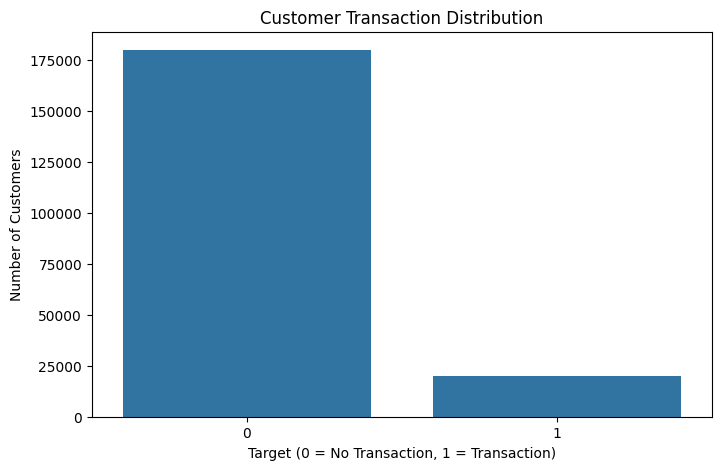

In [13]:
plt.figure(figsize=(8, 5))

sns.countplot(data=train_df, x="target")

plt.title("Customer Transaction Distribution")
plt.xlabel("Target (0 = No Transaction, 1 = Transaction)")
plt.ylabel("Number of Customers")
plt.show()

In [14]:
train_df.drop(columns=["ID_code", "target"]).describe()

,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,var_8,var_9,...,var_190,var_191,var_192,var_193,var_194,var_195,var_196,var_197,var_198,var_199
count,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,...,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000
mean,10.679914,-1.627622,10.715192,6.796529,11.078333,-5.065317,5.408949,16.545850,0.284162,7.567236,...,3.234440,7.438408,1.927839,3.331774,17.993784,-0.142088,2.303335,8.908158,15.870720,-3.326537
std,3.040051,4.050044,2.640894,2.043319,1.623150,7.863267,0.866607,3.418076,3.332634,1.235070,...,4.559922,3.023272,1.478423,3.992030,3.135162,1.429372,5.454369,0.921625,3.010945,10.438015
min,0.408400,-15.043400,2.117100,-0.040200,5.074800,-32.562600,2.347300,5.349700,-10.505500,3.970500,...,-14.093300,-2.691700,-3.814500,-11.783400,8.694400,-5.261000,-14.209600,5.960600,6.299300,-38.852800
25%,8.453850,-4.740025,8.722475,5.254075,9.883175,-11.200350,4.767700,13.943800,-2.317800,6.618800,...,-0.058825,5.157400,0.889775,0.584600,15.629800,-1.170700,-1.946925,8.252800,13.829700,-11.208475
50%,10.524750,-1.608050,10.580000,6.825000,11.108250,-4.833150,5.385100,16.456800,0.393700,7.629600,...,3.203600,7.347750,1.901300,3.396350,17.957950,-0.172700,2.408900,8.888200,15.934050,-2.819550
75%,12.758200,1.358625,12.516700,8.324100,12.261125,0.924800,6.003000,19.102900,2.937900,8.584425,...,6.406200,9.512525,2.949500,6.205800,20.396525,0.829600,6.556725,9.593300,18.064725,4.836800
max,20.315000,10.376800,19.353000,13.188300,16.671400,17.251600,8.447700,27.691800,10.151300,11.150600,...,18.440900,16.716500,8.402400,18.281800,27.928800,4.272900,18.321500,12.000400,26.079100,28.500700


In [15]:
# Remove ID and target from input features
X = train_df.drop(columns=["ID_code", "target"])

# Target variable
y = train_df["target"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (200000, 200)
Target shape: (200000,)


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Validation features:", X_val.shape)
print("Training target:", y_train.shape)
print("Validation target:", y_val.shape)

Training features: (160000, 200)
Validation features: (40000, 200)
Training target: (160000,)
Validation target: (40000,)


In [17]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

print("Model libraries imported successfully!")

Model libraries imported successfully!


In [18]:
model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ))
])

print("Logistic Regression model created successfully!")

Logistic Regression model created successfully!


In [19]:
model.fit(X_train, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [20]:
y_pred = model.predict(X_val)

y_proba = model.predict_proba(X_val)[:, 1]

print("Predictions generated successfully!")
print("First 10 predictions:", y_pred[:10])

Predictions generated successfully!
First 10 predictions: [0 0 0 0 0 0 0 1 0 0]


In [21]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix
)

print("Accuracy:", accuracy_score(y_val, y_pred))
print("Precision:", precision_score(y_val, y_pred, zero_division=0))
print("Recall:", recall_score(y_val, y_pred, zero_division=0))
print("F1 Score:", f1_score(y_val, y_pred, zero_division=0))
print("ROC-AUC:", roc_auc_score(y_val, y_proba))
print("PR-AUC:", average_precision_score(y_val, y_proba))

print("\nClassification Report:")
print(classification_report(y_val, y_pred, zero_division=0))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_pred))

Accuracy: 0.7834
Precision: 0.2865416436845008
Recall: 0.7753731343283582
F1 Score: 0.4184454289166331
ROC-AUC: 0.8598998891036755
PR-AUC: 0.5004371715496038

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.78      0.87     35980
           1       0.29      0.78      0.42      4020

    accuracy                           0.78     40000
   macro avg       0.63      0.78      0.64     40000
weighted avg       0.90      0.78      0.82     40000


Confusion Matrix:
[[28219  7761]
 [  903  3117]]


In [22]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)
import pandas as pd

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

results = []

for threshold in thresholds:
    predictions = (y_proba >= threshold).astype(int)

    results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_val, predictions, zero_division=0
        ),
        "Recall": recall_score(
            y_val, predictions, zero_division=0
        ),
        "F1 Score": f1_score(
            y_val, predictions, zero_division=0
        )
    })

threshold_df = pd.DataFrame(results)
threshold_df.round(4)

,Threshold,Precision,Recall,F1 Score
0,0.3,0.1957,0.9025,0.3216
1,0.4,0.2367,0.8455,0.3699
2,0.5,0.2865,0.7754,0.4184
3,0.6,0.3436,0.6801,0.4565
4,0.7,0.4223,0.5744,0.4867


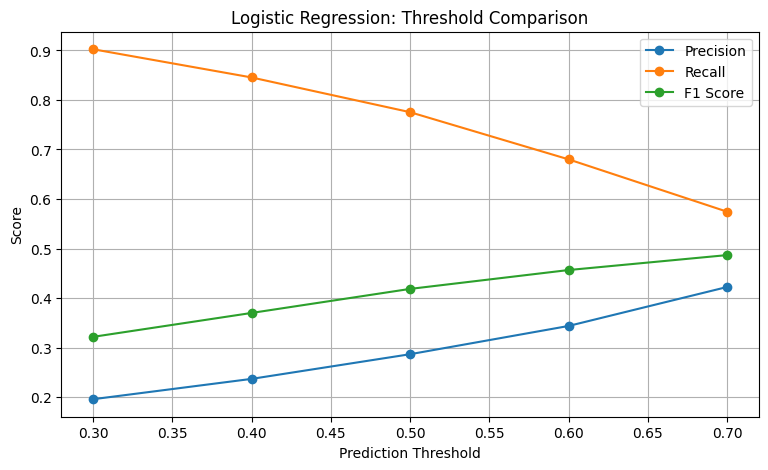

In [23]:
plt.figure(figsize=(9, 5))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1 Score"],
    marker="o",
    label="F1 Score"
)

plt.xlabel("Prediction Threshold")
plt.ylabel("Score")
plt.title("Logistic Regression: Threshold Comparison")
plt.legend()
plt.grid(True)
plt.show()

In [24]:
from sklearn.ensemble import RandomForestClassifier

print("Random Forest imported successfully!")

Random Forest imported successfully!


In [25]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=5,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest training completed!")

Random Forest training completed!


In [26]:
rf_pred = rf_model.predict(X_val)
rf_proba = rf_model.predict_proba(X_val)[:, 1]

print("Predictions generated successfully!")

Predictions generated successfully!


In [27]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix
)

print("Accuracy:", accuracy_score(y_val, rf_pred))
print("Precision:", precision_score(
    y_val, rf_pred, zero_division=0
))
print("Recall:", recall_score(
    y_val, rf_pred, zero_division=0
))
print("F1 Score:", f1_score(
    y_val, rf_pred, zero_division=0
))
print("ROC-AUC:", roc_auc_score(y_val, rf_proba))
print("PR-AUC:", average_precision_score(y_val, rf_proba))

print("\nClassification Report:")
print(classification_report(
    y_val, rf_pred, zero_division=0
))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, rf_pred))

Accuracy: 0.901375
Precision: 0.5230485556238476
Recall: 0.21169154228855722
F1 Score: 0.3013989729059678
ROC-AUC: 0.8089931249809872
PR-AUC: 0.3682329047779755

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.98      0.95     35980
           1       0.52      0.21      0.30      4020

    accuracy                           0.90     40000
   macro avg       0.72      0.60      0.62     40000
weighted avg       0.88      0.90      0.88     40000


Confusion Matrix:
[[35204   776]
 [ 3169   851]]


In [28]:
comparison = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Accuracy": accuracy_score(y_val, y_pred),
        "Precision": precision_score(y_val, y_pred, zero_division=0),
        "Recall": recall_score(y_val, y_pred, zero_division=0),
        "F1 Score": f1_score(y_val, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_val, y_proba),
        "PR-AUC": average_precision_score(y_val, y_proba)
    },
    {
        "Model": "Random Forest",
        "Accuracy": accuracy_score(y_val, rf_pred),
        "Precision": precision_score(y_val, rf_pred, zero_division=0),
        "Recall": recall_score(y_val, rf_pred, zero_division=0),
        "F1 Score": f1_score(y_val, rf_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_val, rf_proba),
        "PR-AUC": average_precision_score(y_val, rf_proba)
    }
])

comparison.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
0,Logistic Regression,0.7834,0.2865,0.7754,0.4184,0.8599,0.5004
1,Random Forest,0.9014,0.5230,0.2117,0.3014,0.8090,0.3682


In [29]:
rf_thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]

rf_results = []

for threshold in rf_thresholds:
    predictions = (rf_proba >= threshold).astype(int)

    rf_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_val, predictions, zero_division=0
        ),
        "Recall": recall_score(
            y_val, predictions, zero_division=0
        ),
        "F1 Score": f1_score(
            y_val, predictions, zero_division=0
        )
    })

rf_threshold_df = pd.DataFrame(rf_results)
rf_threshold_df.round(4)

,Threshold,Precision,Recall,F1 Score
0,0.1,0.1005,1.0000,0.1826
1,0.2,0.1005,1.0000,0.1826
2,0.3,0.1020,0.9995,0.1852
3,0.4,0.1868,0.8488,0.3062
4,0.5,0.5230,0.2117,0.3014
5,0.6,0.9231,0.0030,0.0060
6,0.7,0.0000,0.0000,0.0000


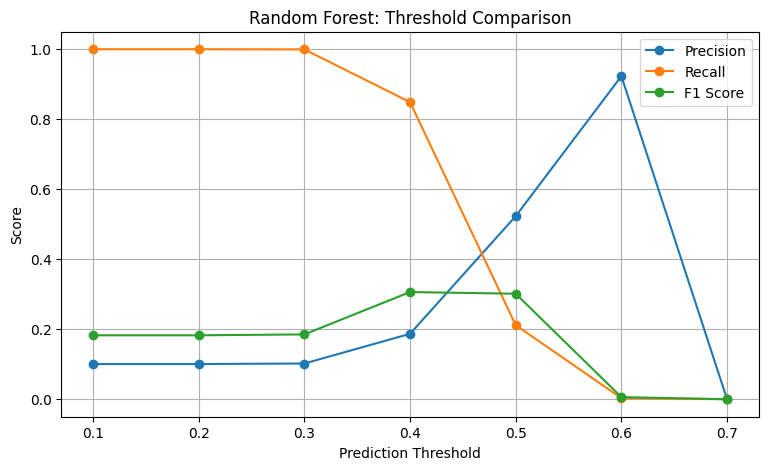

In [30]:
plt.figure(figsize=(9, 5))

plt.plot(
    rf_threshold_df["Threshold"],
    rf_threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    rf_threshold_df["Threshold"],
    rf_threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    rf_threshold_df["Threshold"],
    rf_threshold_df["F1 Score"],
    marker="o",
    label="F1 Score"
)

plt.xlabel("Prediction Threshold")
plt.ylabel("Score")
plt.title("Random Forest: Threshold Comparison")
plt.legend()
plt.grid(True)
plt.show()

In [31]:
# Best threshold for Logistic Regression
best_log_row = threshold_df.loc[
    threshold_df["F1 Score"].idxmax()
]

# Best threshold for Random Forest
best_rf_row = rf_threshold_df.loc[
    rf_threshold_df["F1 Score"].idxmax()
]

print("Logistic Regression:")
print(best_log_row)

print("\nRandom Forest:")
print(best_rf_row)

Logistic Regression:
Threshold    0.700000
Precision    0.422275
Recall       0.574378
F1 Score     0.486720
Name: 4, dtype: float64

Random Forest:
Threshold    0.400000
Precision    0.186816
Recall       0.848756
F1 Score     0.306229
Name: 3, dtype: float64


In [32]:
log_threshold = best_log_row["Threshold"]
rf_threshold = best_rf_row["Threshold"]

log_tuned_pred = (y_proba >= log_threshold).astype(int)
rf_tuned_pred = (rf_proba >= rf_threshold).astype(int)

tuned_comparison = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Threshold": log_threshold,
        "Precision": precision_score(
            y_val, log_tuned_pred, zero_division=0
        ),
        "Recall": recall_score(
            y_val, log_tuned_pred, zero_division=0
        ),
        "F1 Score": f1_score(
            y_val, log_tuned_pred, zero_division=0
        ),
        "ROC-AUC": roc_auc_score(y_val, y_proba),
        "PR-AUC": average_precision_score(y_val, y_proba)
    },
    {
        "Model": "Random Forest",
        "Threshold": rf_threshold,
        "Precision": precision_score(
            y_val, rf_tuned_pred, zero_division=0
        ),
        "Recall": recall_score(
            y_val, rf_tuned_pred, zero_division=0
        ),
        "F1 Score": f1_score(
            y_val, rf_tuned_pred, zero_division=0
        ),
        "ROC-AUC": roc_auc_score(y_val, rf_proba),
        "PR-AUC": average_precision_score(y_val, rf_proba)
    }
])

tuned_comparison.round(4)

,Model,Threshold,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
0,Logistic Regression,0.7,0.4223,0.5744,0.4867,0.8599,0.5004
1,Random Forest,0.4,0.1868,0.8488,0.3062,0.8090,0.3682


In [33]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

final_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ))
])

# Train using the complete dataset
final_model.fit(X, y)

print("Final model trained successfully!")

Final model trained successfully!


In [34]:
# Separate the test features from the ID
X_test = test_df.drop(columns=["ID_code"])

# Ensure the test features match the training features
if set(X_test.columns) != set(X.columns):
    raise ValueError("Training and test features do not match.")

X_test = X_test[X.columns]

print("Test features:", X_test.shape)

Test features: (200000, 200)


In [35]:
test_proba = final_model.predict_proba(X_test)[:, 1]

print("Predictions generated successfully!")
print("First 10 probabilities:", test_proba[:10])

Predictions generated successfully!
First 10 probabilities: [0.68402495 0.73628122 0.32521091 0.70922908 0.39489125 0.02481964
 0.06705002 0.63716885 0.02078295 0.06579153]


In [36]:
from pathlib import Path
import joblib

models_dir = Path("models")
models_dir.mkdir(parents=True, exist_ok=True)

model_path = models_dir / "logistic_regression.joblib"

joblib.dump(final_model, model_path)

print("Model saved to:", model_path)

Model saved to: models\logistic_regression.joblib


In [37]:
outputs_dir = Path("outputs")
outputs_dir.mkdir(parents=True, exist_ok=True)

submission = pd.DataFrame({
    "ID_code": test_df["ID_code"],
    "target": test_proba
})

submission_path = (
    outputs_dir / "customer_transaction_submission.csv"
)

submission.to_csv(submission_path, index=False)

print("Submission saved to:", submission_path)
print(submission.head())
print("Submission shape:", submission.shape)

Submission saved to: outputs\customer_transaction_submission.csv
  ID_code    target
0  test_0  0.684025
1  test_1  0.736281
2  test_2  0.325211
3  test_3  0.709229
4  test_4  0.394891
Submission shape: (200000, 2)


In [38]:
from pathlib import Path
import shutil

# Project root (assuming the notebook is inside notebooks/)
project_dir = Path.cwd().parent

# Create root-level folders
(project_dir / "models").mkdir(exist_ok=True)
(project_dir / "outputs").mkdir(exist_ok=True)

# Move the model
model_source = project_dir / "notebooks/models/logistic_regression.joblib"
model_destination = project_dir / "models/logistic_regression.joblib"

if model_source.exists():
    shutil.move(str(model_source), str(model_destination))

# Move the submission file
csv_source = project_dir / "notebooks/outputs/customer_transaction_submission.csv"
csv_destination = project_dir / "outputs/customer_transaction_submission.csv"

if csv_source.exists():
    shutil.move(str(csv_source), str(csv_destination))

print("Files moved successfully!")

Files moved successfully!
